<a href="https://colab.research.google.com/github/roowan/da-k-means/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering: Detecting Machining Start/End from Dynamometer Data

**About the data:** cutting forces ($F_x$, $F_y$, $F_z$) measured by a dynamometer during a milling
operation, sampled at a fixed time step. Data capture starts before machining begins and ends
after it stops, so the file contains an idle segment, a machining segment, and another idle
segment.

**Goal:** write a function that uses K-Means clustering to find the start and end time of the
actual machining process.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

pd.set_option('display.precision', 6)

## 1. Load and inspect the data

In [ ]:
df = pd.read_csv('Clustering-data.csv', header=None, names=['time', 'Fx', 'Fy', 'Fz'])
df.head()

,time,Fx,Fy,Fz
0,0.00000,-0.000246,-0.000191,-0.001684
1,0.00005,0.000315,0.000290,-0.002486
2,0.00010,0.000315,0.000049,-0.001844
3,0.00015,0.000395,0.000611,-0.001684
4,0.00020,-0.000487,0.000852,-0.000881


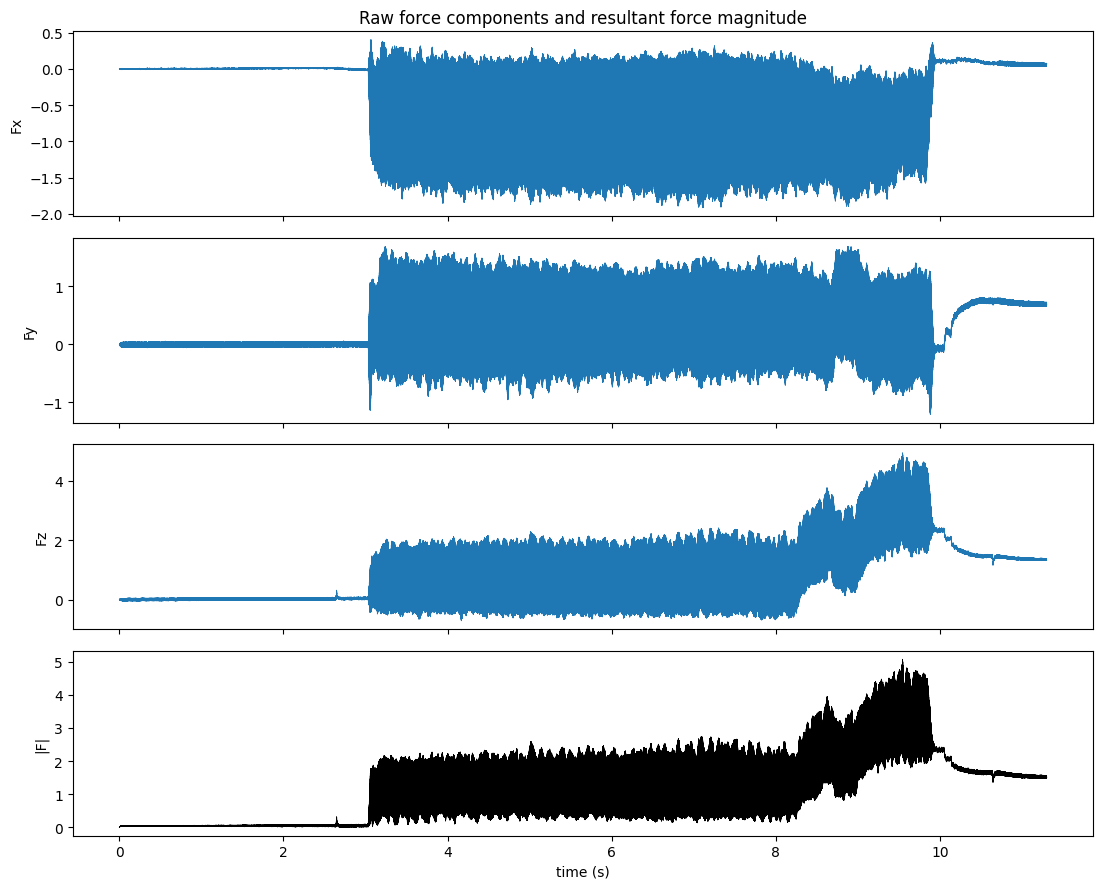

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for ax, col in zip(axes, ['Fx', 'Fy', 'Fz']):
    ax.plot(df['time'], df[col], linewidth=0.5)
    ax.set_ylabel(col)
df['mag'] = np.sqrt(df.Fx**2 + df.Fy**2 + df.Fz**2)
axes[3].plot(df['time'], df['mag'], linewidth=0.5, color='black')
axes[3].set_ylabel('|F|')
axes[3].set_xlabel('time (s)')
axes[0].set_title('Raw force components and resultant force magnitude')
plt.tight_layout()
plt.show()

From the plot, the force signals remain close to a flat, low-noise baseline at the beginning, corresponding to the dynamometer being idle with no cutting. Once the cutter engages with the workpiece, the force level increases and the signal becomes noticeably more noisy and oscillatory, before gradually settling toward the end. However, the tail of the signal does not return completely to zero, indicating a residual static offset that could come from sensor bias or remaining tool load.

Because of this offset, the raw force magnitude is not a reliable feature for applying a single threshold across the entire record. The more consistent difference between the cutting and idle regions is the **local variability**: the cutting region shows much stronger sample-to-sample fluctuations, while the idle regions remain relatively smooth despite having different mean levels. Hence, a **rolling standard deviation** is used as the feature for clustering.


## 2. Feature engineering: local variability of the resultant force

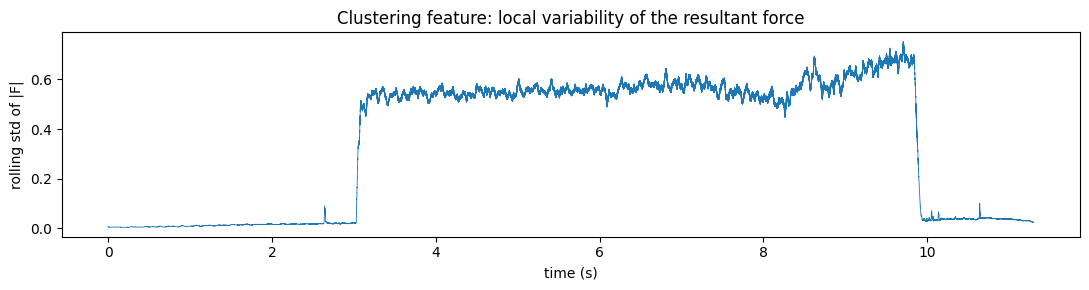

In [ ]:
def rolling_variability(mag, window):
    """Centered rolling standard deviation of the resultant force, used as the
    clustering feature (captures cutting chatter regardless of the mean force level)."""
    return mag.rolling(window, center=True, min_periods=1).std().bfill().ffill()

WINDOW = 200  # ~0.01 s at this sampling rate; a few tooth-passing cycles
df['variability'] = rolling_variability(df['mag'], WINDOW)

plt.figure(figsize=(11, 3))
plt.plot(df['time'], df['variability'], linewidth=0.6)
plt.xlabel('time (s)')
plt.ylabel('rolling std of |F|')
plt.title('Clustering feature: local variability of the resultant force')
plt.tight_layout()
plt.show()

## 3. K-Means clustering to find start/end of machining

In [ ]:
def find_machining_window(csv_path, window=200, n_clusters=2, random_state=0):
    """
    Use K-Means clustering on the local variability of the resultant cutting force
    to find the start and end time of the machining process.

    Parameters
    ----------
    csv_path : str
        Path to the dynamometer CSV file (columns: time, Fx, Fy, Fz, no header).
    window : int
        Number of samples used for the rolling standard-deviation feature.
    n_clusters : int
        Number of K-Means clusters (2 = "idle" vs "machining").
    random_state : int
        Random state for reproducible K-Means initialisation.

    Returns
    -------
    result : dict with keys
        't_start', 't_end'   : detected start/end time of machining (s)
        'df'                 : dataframe with 'mag', 'variability', 'label' columns
        'model'              : the fitted KMeans object
    """
    data = pd.read_csv(csv_path, header=None, names=['time', 'Fx', 'Fy', 'Fz'])
    data['mag'] = np.sqrt(data.Fx**2 + data.Fy**2 + data.Fz**2)
    data['variability'] = rolling_variability(data['mag'], window)

    X = data[['variability']].values
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state).fit(X)
    data['label'] = model.labels_

    # the machining cluster is the one with the higher-variability centroid
    machining_cluster = np.argmax(model.cluster_centers_.flatten())
    machining_idx = np.where(data['label'].values == machining_cluster)[0]

    t_start = data['time'].iloc[machining_idx[0]]
    t_end = data['time'].iloc[machining_idx[-1]]

    return {'t_start': t_start, 't_end': t_end, 'df': data, 'model': model}


result = find_machining_window('Clustering-data.csv')
print(f"Detected machining start: {result['t_start']:.4f} s")
print(f"Detected machining end:   {result['t_end']:.4f} s")
print(f"Duration:                 {result['t_end'] - result['t_start']:.4f} s")

Detected machining start: 3.0490 s
Detected machining end:   9.8863 s
Duration:                 6.8373 s


## 3a. Justifying k = 2: Elbow Method and Silhouette Score

We chose **k = 2** because the machining process has two main states: **idle and cutting**. To support this choice with the data, we also checked the Elbow Method and Silhouette Score.

* **Elbow Method:** We plot the inertia against different values of `k`. Inertia decreases as more clusters are added, but we look for the point where the decrease becomes much smaller. This point is the **“elbow”**, which gives a reasonable value for `k`.

* **Silhouette Score:** This measures how well each data point fits within its own cluster compared with the nearest other cluster. The score ranges from **-1 to 1**, where a higher value means the clusters are better separated. Unlike inertia, the score does not automatically improve just because we increase `k`.


In [ ]:
from sklearn.metrics import silhouette_score

data = result['df']
X_all = data['variability'].values.reshape(-1, 1)

# silhouette is O(n^2) - too slow on 226k points, so score on a random subsample
rng = np.random.RandomState(0)
sample_idx = rng.choice(len(X_all), size=15000, replace=False)
X_sample = X_all[sample_idx]

ks = list(range(1, 8))
inertias = []
silhouettes = [None]  # undefined for k=1

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_all)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouettes.append(silhouette_score(X_sample, km.predict(X_sample)))

for k, inertia, sil in zip(ks, inertias, silhouettes):
    sil_str = f'{sil:.3f}' if sil is not None else '   n/a'
    print(f'k={k}:  inertia={inertia:9.2f}   silhouette={sil_str}')

k=1:  inertia= 16324.73   silhouette=   n/a
k=2:  inertia=   351.75   silhouette=0.931
k=3:  inertia=   165.43   silhouette=0.774
k=4:  inertia=   115.94   silhouette=0.775
k=5:  inertia=    75.09   silhouette=0.683
k=6:  inertia=    55.83   silhouette=0.694
k=7:  inertia=    42.33   silhouette=0.610


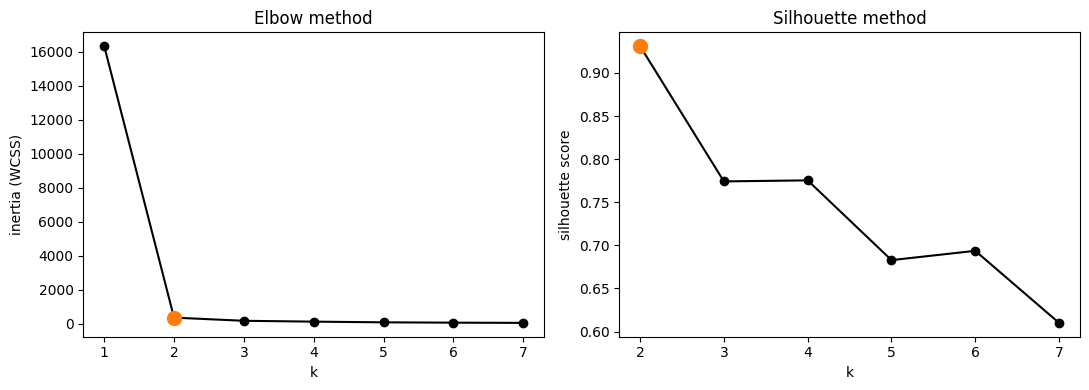

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ks, inertias, marker='o', color='black')
axes[0].plot(2, inertias[1], marker='o', color='tab:orange', markersize=10, zorder=5)
axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia (WCSS)') # within clusters sum of squares
axes[0].set_title('Elbow method')

axes[1].plot(ks[1:], silhouettes[1:], marker='o', color='black')
axes[1].plot(2, silhouettes[1], marker='o', color='tab:orange', markersize=10, zorder=5)
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette score')
axes[1].set_title('Silhouette method')

plt.tight_layout()
plt.show()

### Reading the result

- The inertia drops very sharply from about **16,325 at k = 1** to around **352 at k = 2**, which is a huge improvement. After k = 2, the inertia still decreases, but only by a small amount each time. This makes the **elbow clearly appear at k = 2**.

- The **silhouette score is also highest at k = 2 (about 0.93)** and decreases for larger values of k. A score this close to 1 means the two clusters are very well separated.

So, both the **Elbow Method and Silhouette Score** support **k = 2**, which also matches the physical situation of the data: one cluster for idle and one for machining.


## 4. Visual check of the detected window

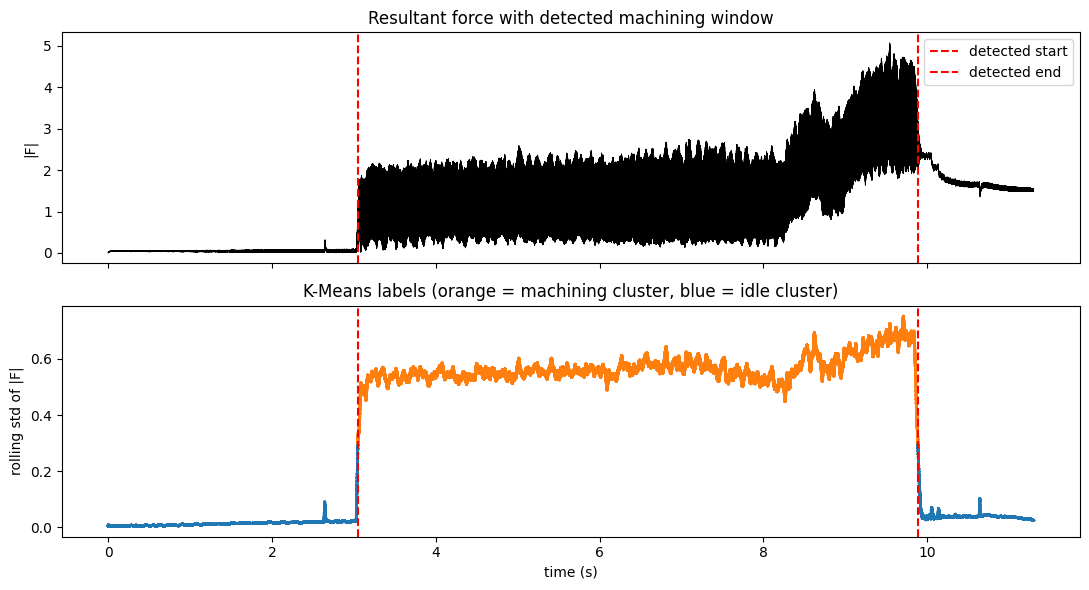

In [ ]:
data = result['df']
t_start, t_end = result['t_start'], result['t_end']

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(data['time'], data['mag'], linewidth=0.5, color='black')
axes[0].axvline(t_start, color='red', linestyle='--', label='detected start')
axes[0].axvline(t_end, color='red', linestyle='--', label='detected end')
axes[0].set_ylabel('|F|')
axes[0].set_title('Resultant force with detected machining window')
axes[0].legend()

colors = np.where(data['label'] == np.argmax(result['model'].cluster_centers_.flatten()),
                   'tab:orange', 'tab:blue')
axes[1].scatter(data['time'], data['variability'], c=colors, s=1)
axes[1].axvline(t_start, color='red', linestyle='--')
axes[1].axvline(t_end, color='red', linestyle='--')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('rolling std of |F|')
axes[1].set_title('K-Means labels (orange = machining cluster, blue = idle cluster)')

plt.tight_layout()
plt.show()

## 5. Conclusion

Clustering the raw force values directly would not work well because the idle force at the end of the signal is slightly different from the idle force at the beginning. Instead, we use the **rolling standard deviation of the resultant force**. This captures how much the force fluctuates, so both idle regions have low variability while the machining region has much higher variability, even if their actual force levels are different.

Because of this, a simple **2-cluster K-Means** model can separate the idle and machining regions and identify the start and end of the cutting process without having to manually choose a force threshold.
